# ex-5: the rotation angle $\sin^2\angle(\hat w_j, e_j)$

Distribution of the bare rotation term — $\hat w_j$ the $j$-th eigenvector (descending) of
$\hat D = C^{1/2}(F^\top F/n)\,C^{1/2}$, $e_j$ the matching axis — for two calibrations:

| model | $\sigma_j$ (ann.) | $c_j$ |
|---|---|---|
| k=3 canonical | 16%, 8%, 6% | 1.25, 1, 1 |
| k=6 realistic | 16%, 10%, 9%, 8%, 6%, 5% | 1.25, 1, 1, 1, 1, 1 |

Factor returns t6 (variance-matched) and gaussian; $n$ from one month to four years of
trading days; 100k replications per cell. Boxes = IQR, line = median, whiskers = q05/q95.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

SEED, N_REPS, CHUNK = 20260717, 100_000, 5_000
N_EXT = [20, 42, 63, 126, 252, 504, 1008]
Q_LEVELS = [0.05, 0.25, 0.50, 0.75, 0.95]
MODELS = {
    "k3": {"sig": np.array([0.16, 0.08, 0.06]), "c": np.array([1.25, 1.0, 1.0]),
           "labels": ["factor 1", "factor 2", "factor 3"]},
    "k6": {"sig": np.array([0.16, 0.10, 0.09, 0.08, 0.06, 0.05]),
           "c": np.array([1.25, 1, 1, 1, 1, 1.0]),
            "labels": ["factor 1", "factor 2", "factor 3", "factor 4", "factor 5", "factor 6"]
        #    "labels": ["market", "momentum", "value", "size", "quality", "investment"]
           },
}

rows = []
for mname, m in MODELS.items():
    sig, c = m["sig"], m["c"]; k = len(sig)
    for d_idx, dist in enumerate(["t6", "normal"]):
        for nv in N_EXT:
            rng = np.random.default_rng([SEED, nv, d_idx, k])
            rot = np.empty((N_REPS, k))
            for i0 in range(0, N_REPS, CHUNK):
                if dist == "t6":
                    F = rng.standard_t(6, size=(CHUNK, nv, k)) / np.sqrt(1.5) * sig
                else:
                    F = rng.standard_normal(size=(CHUNK, nv, k)) * sig
                X = F * np.sqrt(c)
                Dh = np.einsum("rni,rnj->rij", X, X) / nv
                _, vecs = np.linalg.eigh(Dh)
                W = vecs[:, :, ::-1]
                rot[i0:i0+CHUNK] = 1.0 - np.diagonal(W ** 2, axis1=1, axis2=2)
            for j in range(k):
                for lvl in Q_LEVELS:
                    rows.append({"model": mname, "dist": dist, "n": nv, "factor": j + 1,
                                 "quantile": lvl, "value": np.quantile(rot[:, j], lvl)})

tbl = pd.DataFrame(rows)
tbl.to_csv("nb_outputs/ex5_rotation_angle.csv", index=False)
tbl[(tbl["n"] == 63) & (tbl["quantile"].isin([0.50, 0.95]))].pivot_table(
    index=["model", "factor"], columns=["dist", "quantile"], values="value").round(3)

dist         normal            t6       
quantile       0.50   0.95   0.50   0.95
model factor                            
k3    1       0.005  0.024  0.005  0.028
      2       0.029  0.247  0.031  0.568
      3       0.025  0.246  0.026  0.566
k6    1       0.021  0.071  0.022  0.093
      2       0.241  0.953  0.287  0.990
      3       0.451  0.987  0.576  0.996
      4       0.311  0.958  0.408  0.992
      5       0.181  0.807  0.236  0.971
      6       0.106  0.735  0.113  0.942

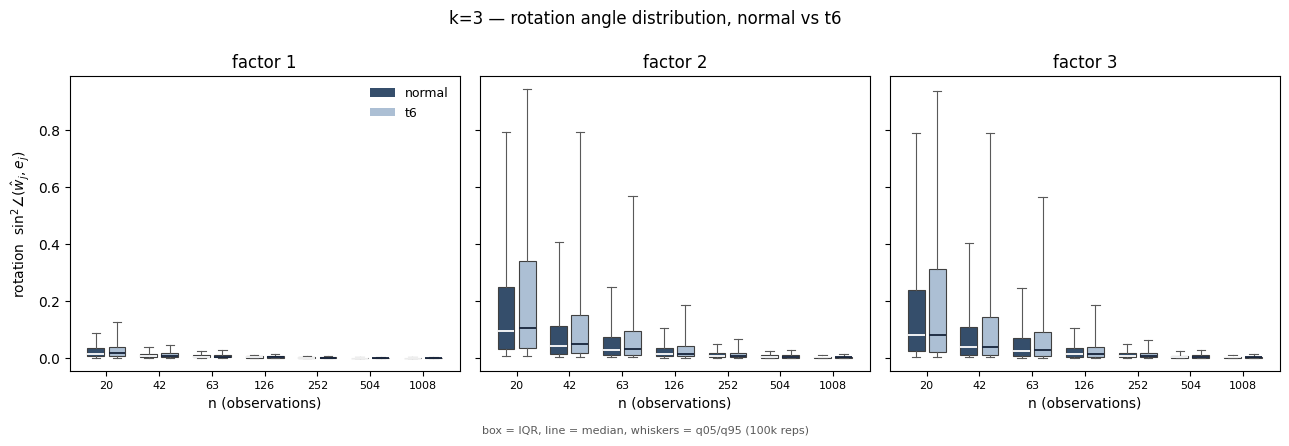

In [4]:
NORMAL, T6 = "#354E6B", "#ACBFD4"

def rotation_bxp(ax, sub_pivot, positions, facecolor, median_color):
    '''Boxplot from precomputed quantiles: box = IQR, line = median, whiskers = q05/q95.'''
    stats = [{"whislo": sub_pivot.loc[nv, 0.05], "q1": sub_pivot.loc[nv, 0.25],
              "med": sub_pivot.loc[nv, 0.50], "q3": sub_pivot.loc[nv, 0.75],
              "whishi": sub_pivot.loc[nv, 0.95], "fliers": []}
             for nv in sub_pivot.index]
    ax.bxp(stats, positions=positions, widths=0.32, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=facecolor, edgecolor="0.25", lw=0.8),
           medianprops=dict(color=median_color, lw=1.3),
           whiskerprops=dict(color="0.35", lw=0.8), capprops=dict(color="0.35", lw=0.8))

def rotation_boxplot_figure(mname, nrows, ncols, figsize, out_name):
    m = MODELS[mname]; k = len(m["sig"])
    x = np.arange(len(N_EXT))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True,
                             squeeze=False)
    for j, ax in enumerate(axes.ravel(), start=1):
        for dist, fc, off, mc in [("normal", NORMAL, -0.2, "white"),
                                  ("t6", T6, 0.2, "#16233A")]:
            sub = (tbl[(tbl["model"] == mname) & (tbl["dist"] == dist)
                       & (tbl["factor"] == j)]
                   .pivot(index="n", columns="quantile", values="value").loc[N_EXT])
            rotation_bxp(ax, sub, x + off, fc, mc)
        ax.set_title(f"factor {j} ({m['labels'][j-1]})" if mname == "k7"
                     else m["labels"][j-1])
        ax.set_xticks(x); ax.set_xticklabels(N_EXT, fontsize=8)
        if j > (nrows - 1) * ncols:
            ax.set_xlabel("n (observations)")
    for row in axes:
        row[0].set_ylabel(r"rotation  sin$^2\angle(\hat w_j, e_j)$")
    axes[0, 0].legend(handles=[Patch(facecolor=NORMAL, label="normal"),
                               Patch(facecolor=T6, label="t6")], frameon=False, fontsize=9)
    fig.suptitle(f"{mname[0]}={mname[1]} — rotation angle distribution, normal vs t6", y=0.99)
    fig.text(0.5, -0.02, "box = IQR, line = median, whiskers = q05/q95 (100k reps)",
             ha="center", fontsize=8, color="0.35")
    fig.tight_layout()
    fig.savefig(f"nb_outputs/{out_name}", dpi=200, bbox_inches="tight")
    plt.show()

rotation_boxplot_figure("k3", 1, 3, (13, 4.2), "ex5_rotation_boxplots_k3.png")

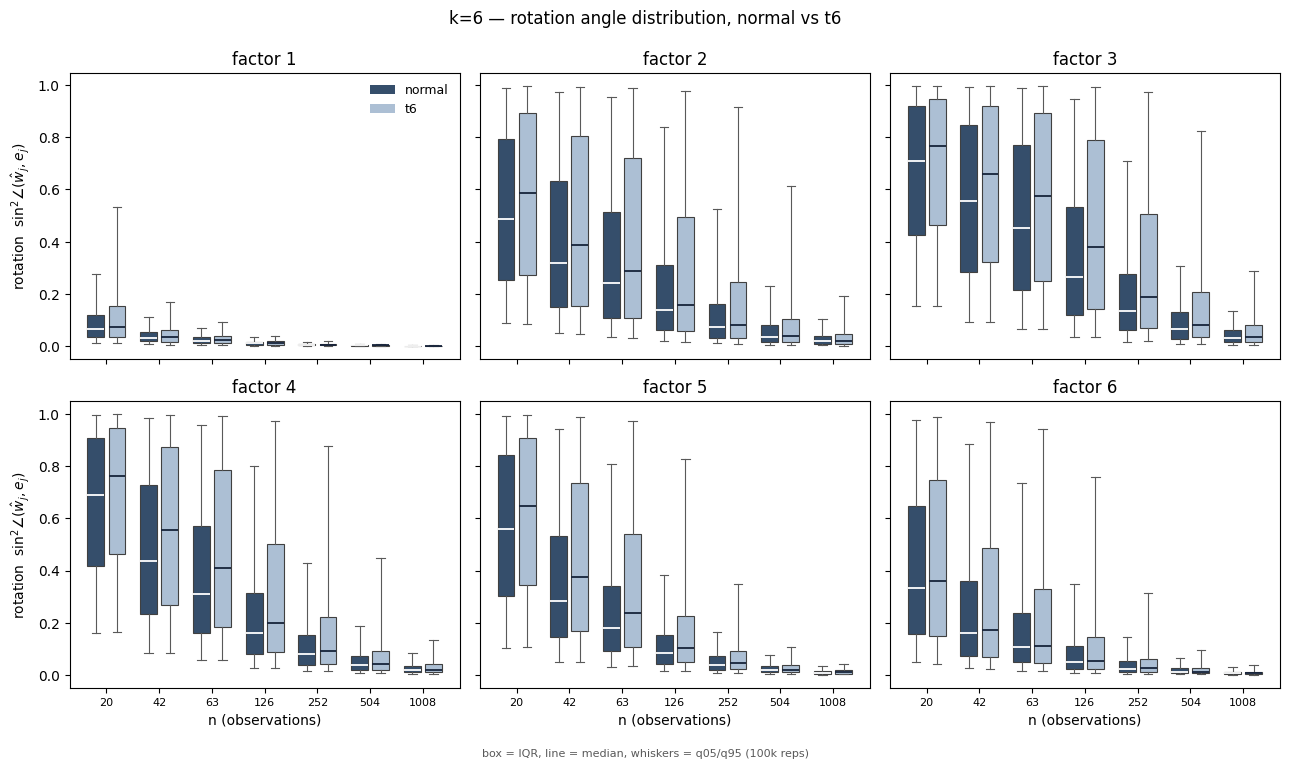

In [5]:
rotation_boxplot_figure("k6", 2, 3, (13, 7.4), "ex5_rotation_boxplots_k6.png")